# Klasifikasi Topik Keluhan Pelanggan IndiHome

**Analisis Sentimen Keluhan Pelanggan IndiHome pada Media Sosial X (Twitter) Menggunakan Metode Support Vector Machine**

---

Notebook ini mencakup 3 tahap:
1. **Preprocessing** - membersihkan teks tweet
2. **Feature Extraction** - mengubah teks jadi angka (TF-IDF)
3. **Training & Evaluasi** - melatih model SVM dan mengukur performanya

Dataset: 799 tweet keluhan pelanggan IndiHome dari Twitter/X, sudah dilabeli ke dalam 5 kategori.

## Install & Import Library

In [2]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter

# Library untuk preprocessing Bahasa Indonesia
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Library untuk machine learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Konfigurasi visual grafik
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Download data stopwords Bahasa Indonesia dari NLTK
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rizki\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. Load Dataset

In [3]:
nama_file = 'indihome_care_20260517_222612_Label FIX 2.csv'
df = pd.read_csv(nama_file, encoding='utf-8-sig')

print(f"Dataset berhasil dimuat: {len(df)} baris")
print(f"Kolom yang tersedia: {list(df.columns)}")
df.head()

Dataset berhasil dimuat: 799 baris
Kolom yang tersedia: ['tweet_id', 'tanggal', 'nama', 'username', 'tweet', 'reply', 'retweet', 'like', 'link', 'query', 'date_window', 'label']


,tweet_id,tanggal,nama,username,tweet,reply,retweet,like,link,query,date_window,label
0,"=""1620208363694084097""",2023-01-30T23:52:30.000Z,JOYBOY,@yudaudaw,Udah saya coba lebih dari 3x mas. Ga ada perub...,1,0,0,https://x.com/yudaudaw/status/1620208363694084097,(@IndiHomeCare) lang:id -filter:media -filter:...,2023-01-01_2023-01-31,Customer Service
1,"=""1620207280309567488""",2023-01-30T23:48:12.000Z,JOYBOY,@yudaudaw,@IndiHome @IndiHomeCare bayar internet mahal2 ...,1,0,0,https://x.com/yudaudaw/status/1620207280309567488,(@IndiHomeCare) lang:id -filter:media -filter:...,2023-01-01_2023-01-31,Gangguan Jaringan
2,"=""1620205891890069504""",2023-01-30T23:42:41.000Z,Heri Nurhisyam,@HeriNurhisyam,@IndiHomeCare internet di Jl. P. Samudera 3 Pa...,2,0,0,https://x.com/HeriNurhisyam/status/16202058918...,(@IndiHomeCare) lang:id -filter:media -filter:...,2023-01-01_2023-01-31,Gangguan Jaringan
3,"=""1620199347668553729""",2023-01-30T23:16:40.000Z,Indra key,@indra_heartkey,@IndiHomeCare Cek DM min Los di modem,1,0,0,https://x.com/indra_heartkey/status/1620199347...,(@IndiHomeCare) lang:id -filter:media -filter:...,2023-01-01_2023-01-31,Gangguan Jaringan
4,"=""1620197474693697536""",2023-01-30T23:09:14.000Z,Nurisman,@Isman_RedP8,Sdh menyala tp tetap no connection min,1,0,0,https://x.com/Isman_RedP8/status/1620197474693...,(@IndiHomeCare) lang:id -filter:media -filter:...,2023-01-01_2023-01-31,Gangguan Jaringan


## 1.5 Exploratory Data Analysis (EDA)

Sebelum melakukan preprocessing dan training, kita perlu **memahami karakteristik dataset** terlebih dahulu.
Tahap EDA ini akan membantu kita:

1. Mengetahui distribusi setiap kategori keluhan
2. Memahami karakteristik panjang tweet
3. Mengidentifikasi kata-kata yang sering muncul
4. Melihat pola temporal (kapan keluhan banyak muncul)
5. Mengetahui engagement metrics (likes, retweets, replies)

EDA yang baik akan memberi insight untuk bab pembahasan laporan.

In [7]:
# Info dataset
print("Informasi Dataset")

print(f"Jumlah baris (tweet)  : {len(df)}")
print(f"Jumlah kolom          : {len(df.columns)}")
print(f"Periode data          : {df['tanggal'].min()[:10]} sampai {df['tanggal'].max()[:10]}")
print(f"Jumlah kategori label : {df['label'].nunique()}")

Informasi Dataset
Jumlah baris (tweet)  : 799
Jumlah kolom          : 12
Periode data          : 2023-01-30 sampai 2026-05-10
Jumlah kategori label : 5


In [5]:
print("Tipe data tiap kolom:")
print(df.dtypes)

Tipe data tiap kolom:
tweet_id       object
tanggal        object
nama           object
username       object
tweet          object
reply           int64
retweet         int64
like            int64
link           object
query          object
date_window    object
label          object
dtype: object


In [6]:
print("Periksa missing values:")
print(df.isnull().sum())

Periksa missing values:
tweet_id       0
tanggal        0
nama           1
username       0
tweet          0
reply          0
retweet        0
like           0
link           0
query          0
date_window    0
label          0
dtype: int64


### 1.5.1 Distribusi Kategori Keluhan

Visualisasi distribusi label dalam dua format: **bar chart** (jumlah absolut) dan **pie chart** (proporsi persentase).
Ini membantu memahami apakah dataset seimbang atau tidak.

Distribusi kategori keluhan:
  Gangguan Jaringan        :  497 (62.20%)
  Customer Service         :  166 (20.78%)
  Lainnya                  :   57 ( 7.13%)
  Masalah Tagihan          :   44 ( 5.51%)
  Pemutusan                :   35 ( 4.38%)


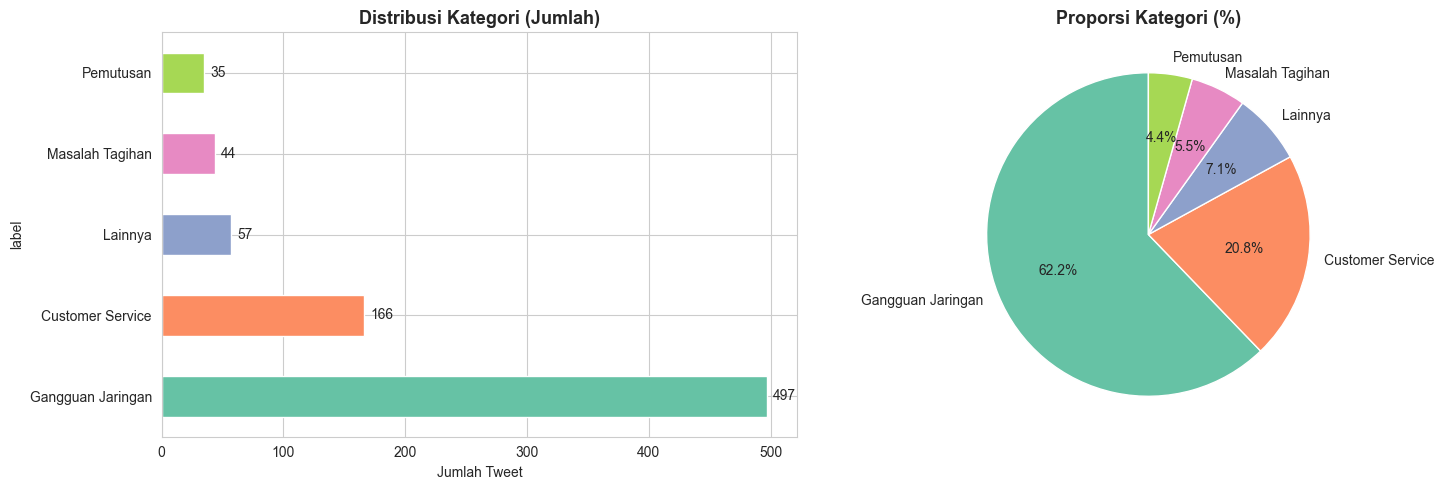

In [8]:
# Hitung distribusi label
distribusi = df['label'].value_counts()
print("Distribusi kategori keluhan:")
for kategori, jumlah in distribusi.items():
    persen = jumlah / len(df) * 100
    print(f"  {kategori:25s}: {jumlah:4d} ({persen:5.2f}%)")

# Visualisasi: bar chart + pie chart bersebelahan
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
warna = sns.color_palette('Set2', len(distribusi))
distribusi.plot(kind='barh', ax=axes[0], color=warna)
axes[0].set_title('Distribusi Kategori (Jumlah)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Tweet')
for i, v in enumerate(distribusi.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Pie chart
axes[1].pie(distribusi.values, labels=distribusi.index, autopct='%1.1f%%',
            colors=warna, startangle=90)
axes[1].set_title('Proporsi Kategori (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_distribusi_label.png', dpi=120, bbox_inches='tight')
plt.show()

### 1.5.2 Analisis Panjang Tweet

Berapa karakter dan kata rata-rata dalam tweet keluhan?
Apakah tweet panjang dan pendek punya pola yang berbeda per kategori?

Statistik panjang tweet:
       panjang_karakter  jumlah_kata
count            799.00       799.00
mean             106.14        16.76
std               66.85        10.59
min               18.00         2.00
25%               54.00         8.00
50%               87.00        14.00
75%              140.00        23.00
max              280.00        54.00



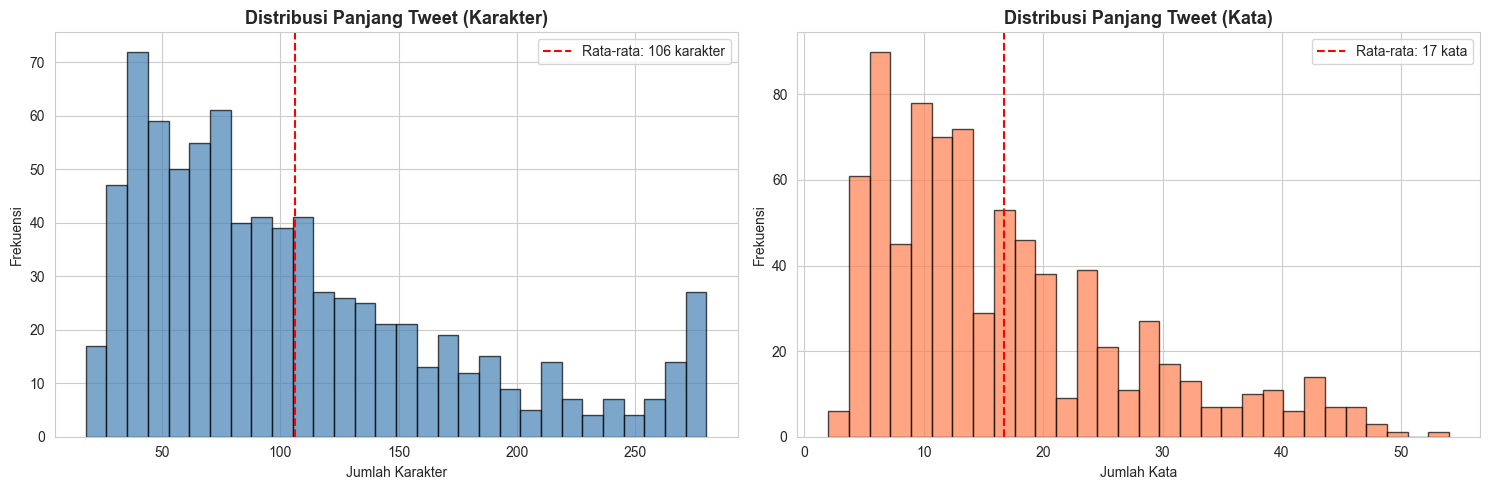

In [9]:
# Hitung panjang tweet (jumlah karakter dan jumlah kata)
df['panjang_karakter'] = df['tweet'].astype(str).str.len()
df['jumlah_kata'] = df['tweet'].astype(str).str.split().str.len()

# Statistik ringkasan
print("Statistik panjang tweet:")
print(df[['panjang_karakter', 'jumlah_kata']].describe().round(2))
print()

# Visualisasi: 2 histogram bersebelahan
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['panjang_karakter'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['panjang_karakter'].mean(), color='red', linestyle='--',
                label=f'Rata-rata: {df["panjang_karakter"].mean():.0f} karakter')
axes[0].set_title('Distribusi Panjang Tweet (Karakter)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

axes[1].hist(df['jumlah_kata'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(df['jumlah_kata'].mean(), color='red', linestyle='--',
                label=f'Rata-rata: {df["jumlah_kata"].mean():.0f} kata')
axes[1].set_title('Distribusi Panjang Tweet (Kata)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_panjang_tweet.png', dpi=120, bbox_inches='tight')
plt.show()

### 1.5.3 Perbandingan Panjang Tweet per Kategori

Apakah tiap kategori keluhan punya karakteristik panjang yang berbeda?
Misalnya, apakah keluhan billing biasanya lebih panjang dari keluhan jaringan?

C:\Users\rizki\AppData\Local\Temp\ipykernel_2520\214854152.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='label', x='panjang_karakter', ax=axes[0], palette='Set2')
C:\Users\rizki\AppData\Local\Temp\ipykernel_2520\214854152.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='label', x='jumlah_kata', ax=axes[1], palette='Set2')


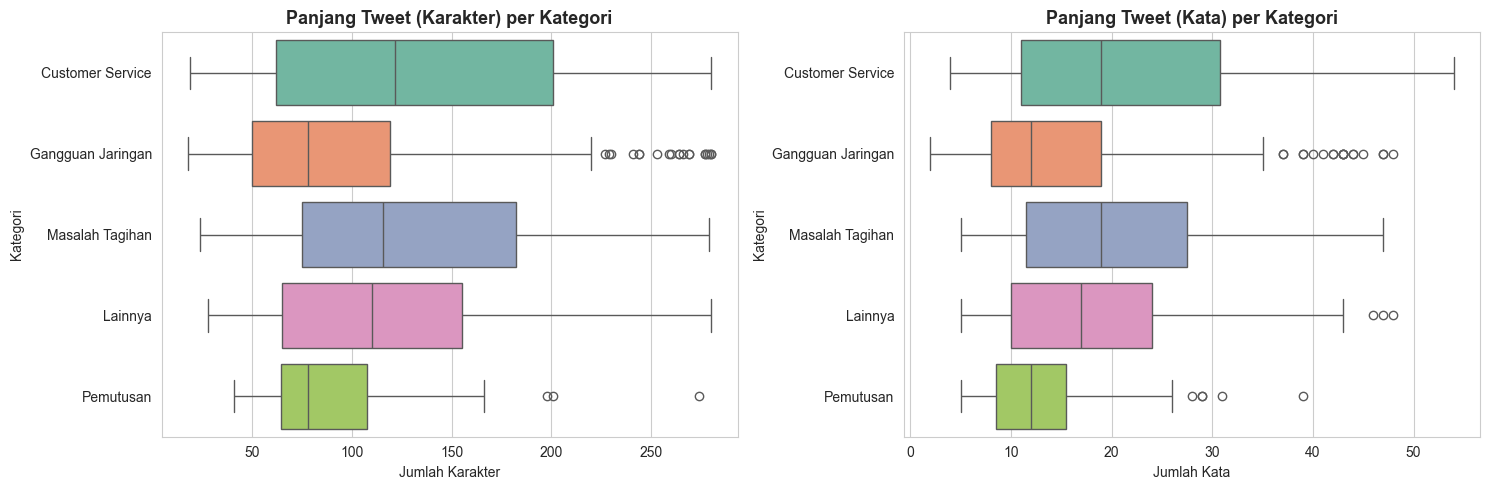

Rata-rata panjang tweet per kategori:
                   panjang_karakter  jumlah_kata
label                                           
Customer Service              134.6         21.4
Gangguan Jaringan              93.1         14.7
Lainnya                       122.3         19.6
Masalah Tagihan               132.9         21.0
Pemutusan                      96.8         14.0


In [10]:
# Boxplot panjang tweet per kategori
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, y='label', x='panjang_karakter', ax=axes[0], palette='Set2')
axes[0].set_title('Panjang Tweet (Karakter) per Kategori', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Kategori')

sns.boxplot(data=df, y='label', x='jumlah_kata', ax=axes[1], palette='Set2')
axes[1].set_title('Panjang Tweet (Kata) per Kategori', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Kategori')

plt.tight_layout()
plt.savefig('eda_panjang_per_kategori.png', dpi=120, bbox_inches='tight')
plt.show()

# Rata-rata per kategori
print("Rata-rata panjang tweet per kategori:")
print(df.groupby('label')[['panjang_karakter', 'jumlah_kata']].mean().round(1))

### 1.5.4 Kata yang Paling Sering Muncul (Sebelum Preprocessing)

Melihat 20 kata yang paling sering muncul di seluruh dataset tweet **mentah** (sebelum dibersihkan).
Banyak kata yang muncul adalah kata umum (yang, di, ke) - ini menunjukkan kenapa preprocessing diperlukan.

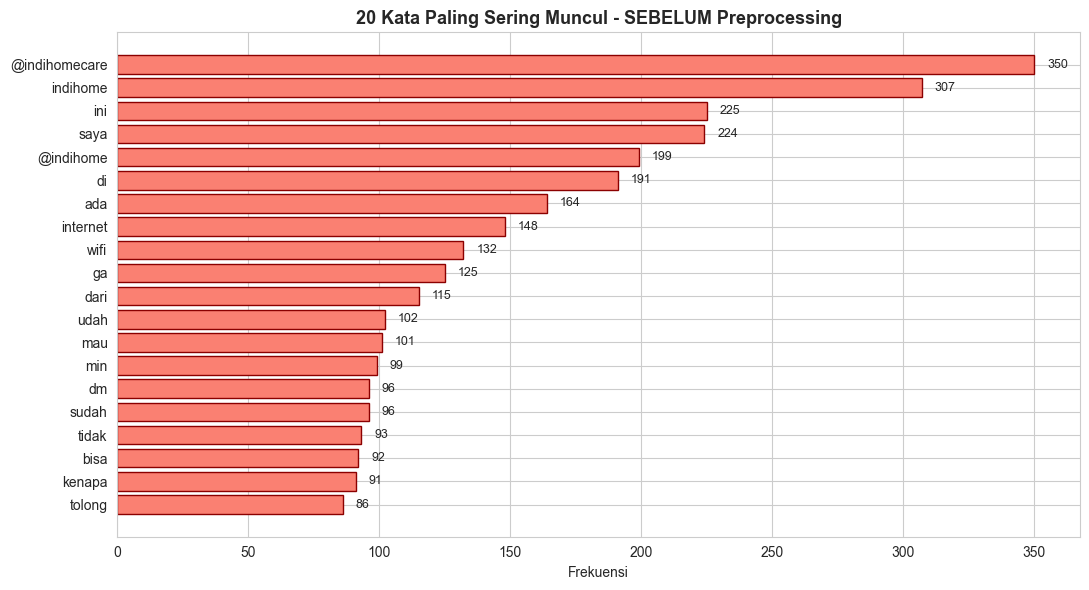

Catatan: banyak kata umum seperti 'yang', 'di', 'saya' - ini akan dihilangkan saat preprocessing.


In [11]:
# Gabung semua tweet jadi satu string besar, lalu hitung kata paling sering
semua_kata_mentah = ' '.join(df['tweet'].astype(str)).lower().split()
counter_mentah = Counter(semua_kata_mentah)
top20_mentah = counter_mentah.most_common(20)

# Visualisasi
kata, jumlah = zip(*top20_mentah)
plt.figure(figsize=(11, 6))
bars = plt.barh(range(len(kata)), jumlah, color='salmon', edgecolor='darkred')
plt.yticks(range(len(kata)), kata)
plt.gca().invert_yaxis()
plt.title('20 Kata Paling Sering Muncul - SEBELUM Preprocessing', fontsize=13, fontweight='bold')
plt.xlabel('Frekuensi')

# Tampilkan angka di ujung bar
for i, (bar, jml) in enumerate(zip(bars, jumlah)):
    plt.text(jml + 5, i, str(jml), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_top20_sebelum.png', dpi=120, bbox_inches='tight')
plt.show()

print("Catatan: banyak kata umum seperti 'yang', 'di', 'saya' - ini akan dihilangkan saat preprocessing.")

### 1.5.5 Pola Temporal Keluhan

Kapan keluhan paling banyak muncul? Apakah ada pola tertentu per bulan atau tahun?
Insight ini bisa jadi pembahasan menarik di laporan (misal: lonjakan keluhan saat ada gangguan besar).

C:\Users\rizki\AppData\Local\Temp\ipykernel_2520\4022256026.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['tahun_bulan'] = df['tanggal_parsed'].dt.to_period('M').astype(str)


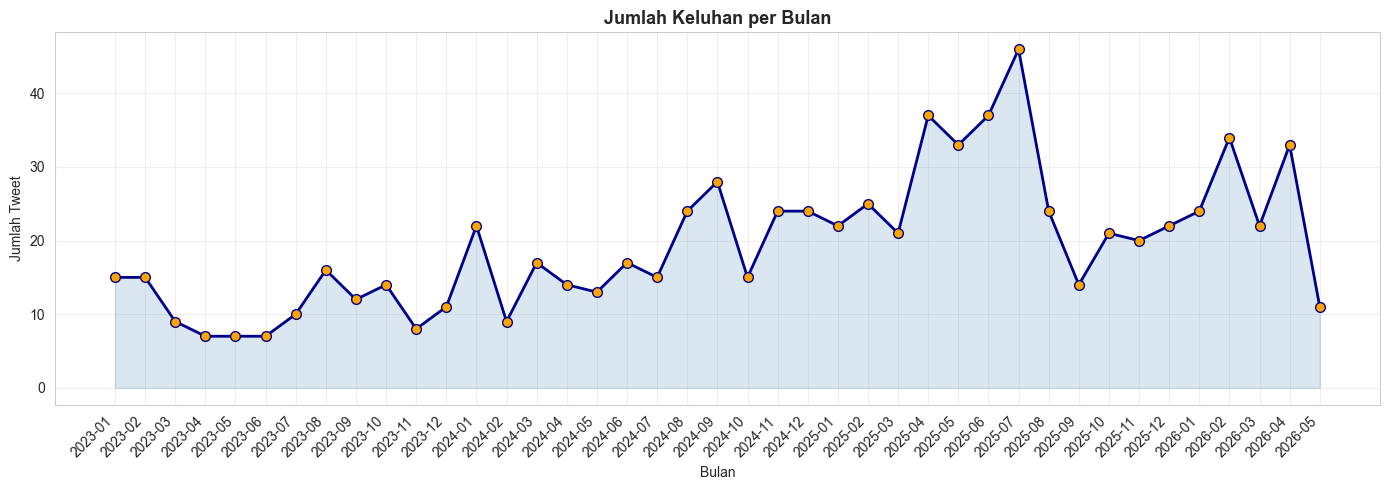

Bulan dengan keluhan TERBANYAK : 2025-07 (46 tweet)
Bulan dengan keluhan TERSEDIKIT: 2023-04 (7 tweet)


In [12]:
# Parse tanggal jadi datetime
df['tanggal_parsed'] = pd.to_datetime(df['tanggal'], errors='coerce')
df['tahun_bulan'] = df['tanggal_parsed'].dt.to_period('M').astype(str)

# Hitung jumlah tweet per bulan
per_bulan = df['tahun_bulan'].value_counts().sort_index()

# Visualisasi line chart
plt.figure(figsize=(14, 5))
plt.plot(per_bulan.index, per_bulan.values, marker='o', linewidth=2,
         color='darkblue', markerfacecolor='orange', markersize=7)
plt.fill_between(range(len(per_bulan)), per_bulan.values, alpha=0.2, color='steelblue')
plt.title('Jumlah Keluhan per Bulan', fontsize=13, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Tweet')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_temporal.png', dpi=120, bbox_inches='tight')
plt.show()

# Bulan dengan keluhan terbanyak
print(f"Bulan dengan keluhan TERBANYAK : {per_bulan.idxmax()} ({per_bulan.max()} tweet)")
print(f"Bulan dengan keluhan TERSEDIKIT: {per_bulan.idxmin()} ({per_bulan.min()} tweet)")

### 1.5.6 Heatmap: Distribusi Kategori per Bulan

Heatmap menunjukkan **kombinasi** antara bulan dan kategori - kategori mana yang dominan di bulan tertentu.
Berguna untuk mengidentifikasi pola: misalnya, kategori "Pemasangan" mungkin spike di awal tahun.

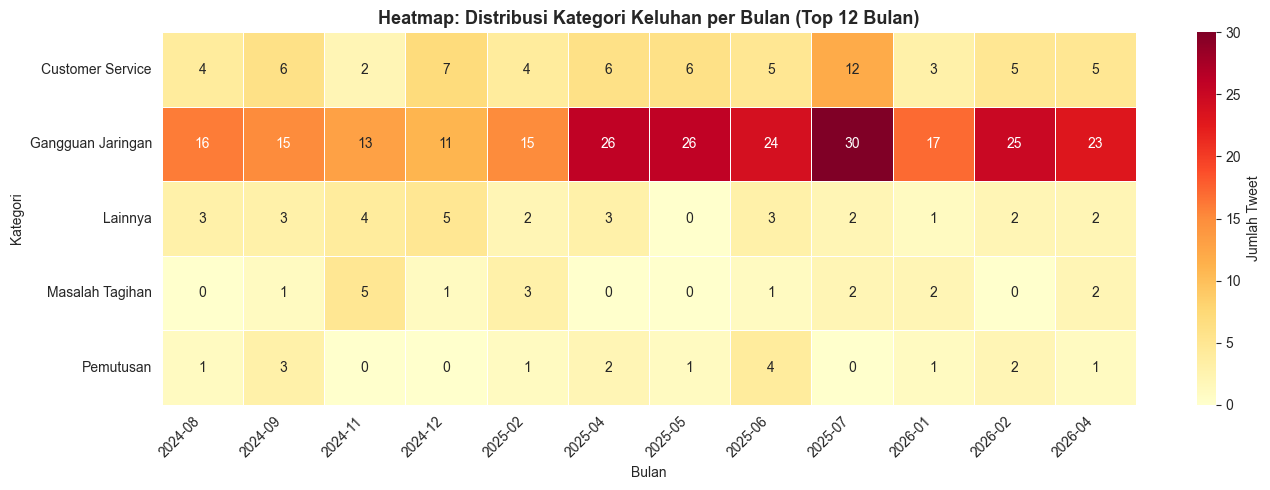

In [13]:
# Buat cross-tabulation kategori x bulan
heatmap_data = pd.crosstab(df['label'], df['tahun_bulan'])

# Ambil hanya bulan yang punya data signifikan (top 12 bulan tersibuk)
top_bulan = df['tahun_bulan'].value_counts().head(12).index.sort_values()
heatmap_subset = heatmap_data[top_bulan]

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_subset, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Jumlah Tweet'}, linewidths=0.5)
plt.title('Heatmap: Distribusi Kategori Keluhan per Bulan (Top 12 Bulan)',
          fontsize=13, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Kategori')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### 1.5.7 Engagement Metrics

Berapa rata-rata like, retweet, dan reply tiap tweet keluhan?
Apakah keluhan tertentu mendapat lebih banyak perhatian publik?

Statistik engagement:
        reply  retweet    like
count  799.00   799.00  799.00
mean     1.06     0.01    0.07
std      0.71     0.13    0.34
min      0.00     0.00    0.00
25%      1.00     0.00    0.00
50%      1.00     0.00    0.00
75%      1.00     0.00    0.00
max      6.00     2.00    5.00



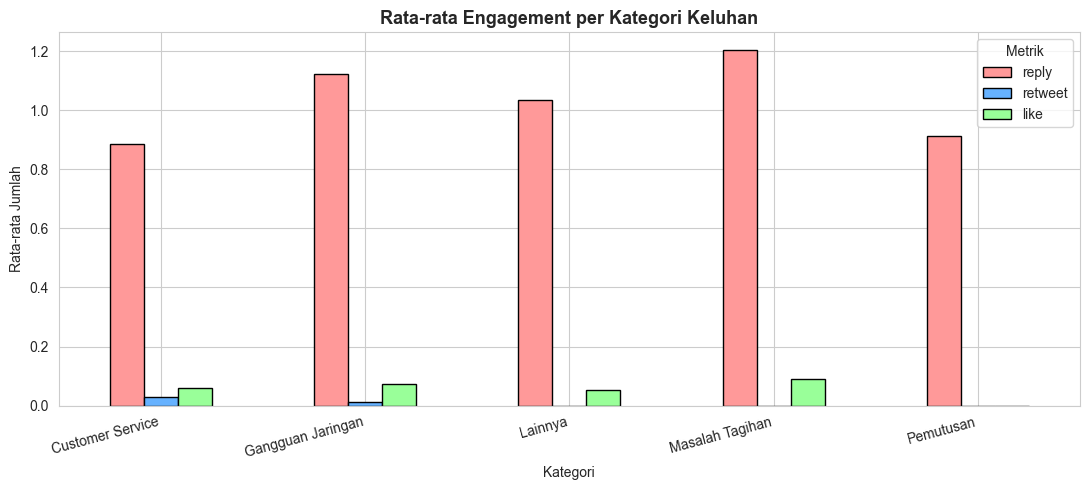

5 Tweet dengan LIKE TERBANYAK:

[Gangguan Jaringan] Like: 5, RT: 0
  Tweet: indihome ini apa ya cok ya, habisnya pas banget wktu maintenance.. begitu mau bayar malah gabisa, ada yg sama ga sih? at...

[Gangguan Jaringan] Like: 4, RT: 0
  Tweet: Pengen nanya dong memang wifi Indihome ada gangguan massal yahh se Indonesia?...

[Gangguan Jaringan] Like: 2, RT: 0
  Tweet: Sumpah ya demi apapun Indihome ini NYEBELIN BGT PANTEK elu telat bayar bntar doang langsung di putus. Tapi wifi mereka i...

[Gangguan Jaringan] Like: 2, RT: 0
  Tweet: Indihome biasanya bagus dah, kok tiba tiba LOS nya kedap kedip ya, udah coba restart dan cabut kabel juga kaga ngaruh, k...

[Masalah Tagihan] Like: 2, RT: 0
  Tweet: Bagus apanya, gw pernah kena tagihan indihome hampir 1jt gara-gara add-on yg gak pernah gw pasang, pas disamperin minta ...


In [14]:
# Convert ke numerik (kalau ada 'K' di angka, perlu diparse manual,
# tapi biasanya untuk dataset ini langsung angka)
for kol in ['reply', 'retweet', 'like']:
    df[kol] = pd.to_numeric(df[kol], errors='coerce').fillna(0).astype(int)

# Statistik
print("Statistik engagement:")
print(df[['reply', 'retweet', 'like']].describe().round(2))
print()

# Visualisasi: rata-rata engagement per kategori
engagement = df.groupby('label')[['reply', 'retweet', 'like']].mean()

fig, ax = plt.subplots(figsize=(11, 5))
engagement.plot(kind='bar', ax=ax, color=['#FF9999', '#66B2FF', '#99FF99'],
                edgecolor='black')
ax.set_title('Rata-rata Engagement per Kategori Keluhan', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori')
ax.set_ylabel('Rata-rata Jumlah')
ax.legend(title='Metrik')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('eda_engagement.png', dpi=120, bbox_inches='tight')
plt.show()

# Top 5 tweet paling viral (berdasarkan like)
print("5 Tweet dengan LIKE TERBANYAK:")
top_viral = df.nlargest(5, 'like')[['label', 'like', 'retweet', 'tweet']]
for idx, row in top_viral.iterrows():
    print(f"\n[{row['label']}] Like: {row['like']}, RT: {row['retweet']}")
    print(f"  Tweet: {row['tweet'][:120]}...")

### 1.5.8 Ringkasan Insight EDA

Berdasarkan eksplorasi di atas, beberapa insight penting:

- **Distribusi label tidak seimbang** (class imbalance) - perlu ditangani dengan `class_weight='balanced'` saat training
- **Panjang tweet bervariasi** - beberapa kategori cenderung lebih panjang dari yang lain
- **Banyak kata umum (stopwords)** mendominasi data mentah - preprocessing wajib dilakukan
- **Pola temporal** menunjukkan keluhan tidak merata sepanjang waktu
- **Engagement metrics** memberi gambaran tweet mana yang viral

Lanjut ke tahap preprocessing untuk membersihkan teks.

## 1.6 Data Cleaning (Pembersihan Dataset)

Setelah memahami karakteristik dataset lewat EDA, sekarang kita perlu **membersihkan dataset di level baris**
sebelum lanjut ke text preprocessing. Tahap ini berbeda dengan text preprocessing:

- **Data cleaning** = membersihkan dataset (hapus duplikat, missing values, baris tidak valid)
- **Text preprocessing** = membersihkan isi teks per tweet (URL, mention, stopwords, dll)

Langkah-langkah data cleaning:
1. Cek dan tangani **missing values**
2. Hapus **baris duplikat**
3. Filter tweet yang **terlalu pendek** (kemungkinan noise)
4. Hapus baris dengan **label tidak valid**
5. Cek konsistensi data
6. Bandingkan ukuran dataset **sebelum vs sesudah** cleaning

### 1.6.1 Catat Jumlah Data Awal

Simpan jumlah baris awal sebagai baseline untuk perbandingan setelah cleaning.

In [15]:
# Simpan jumlah awal untuk reporting nanti
jumlah_awal = len(df)
log_cleaning = {'Data awal': jumlah_awal}

print(f"Jumlah baris awal: {jumlah_awal}")
print(f"Jumlah kolom     : {len(df.columns)}")

Jumlah baris awal: 799
Jumlah kolom     : 16


### 1.6.2 Cek dan Tangani Missing Values

Memeriksa apakah ada nilai kosong (NaN) di setiap kolom.
Baris dengan kolom penting kosong (`tweet`, `label`) akan dihapus karena tidak bisa dipakai untuk training.

Missing Values per Kolom
nama    1
dtype: int64



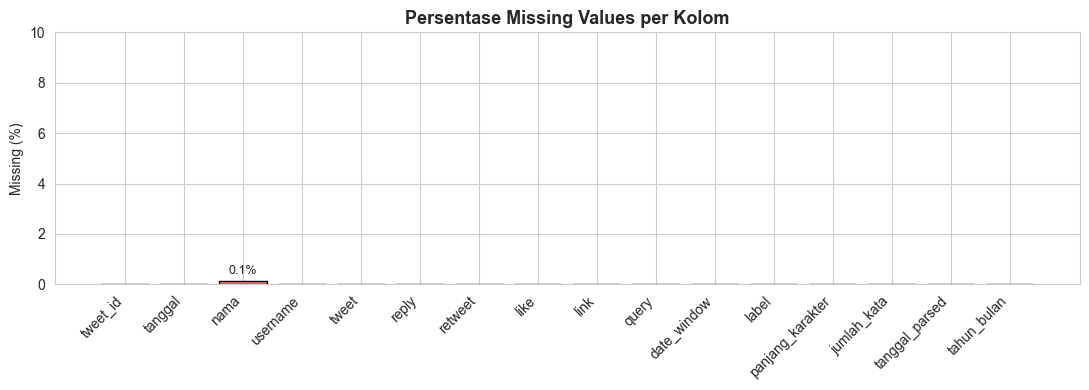


Baris dihapus karena missing values: 0
Sisa data: 799


In [ ]:
# Cek missing values di tiap kolom
print("Missing Values per Kolom")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing values!")
print()

# Visualisasi missing values
fig, ax = plt.subplots(figsize=(11, 4))
missing_pct = (df.isnull().sum() / len(df) * 100)
bars = ax.bar(missing_pct.index, missing_pct.values,
              color=['salmon' if v > 0 else 'lightgreen' for v in missing_pct.values],
              edgecolor='black')
ax.set_title('Persentase Missing Values per Kolom', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.set_ylim(0, max(missing_pct.max() + 5, 10))
plt.xticks(rotation=45, ha='right')

for bar, pct in zip(bars, missing_pct.values):
    if pct > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{pct:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('clean_missing_values.png', dpi=120, bbox_inches='tight')
plt.show()

# Hapus baris dengan kolom kritikal kosong
sebelum = len(df)
df = df.dropna(subset=['tweet', 'label']).reset_index(drop=True)
sesudah = len(df)
dihapus = sebelum - sesudah

log_cleaning['Setelah hapus missing values'] = sesudah
print(f"\nBaris dihapus karena missing values: {dihapus}")
print(f"Sisa data: {sesudah}")

### 1.6.3 Hapus Baris Duplikat

Cek apakah ada tweet yang **persis sama** muncul lebih dari sekali.
Duplikat bisa membuat model overfit ke tweet tertentu, atau membuat evaluasi tidak adil
(tweet yang sama bisa muncul di training dan testing).

In [18]:
# Cek duplikat berdasarkan isi tweet
duplikat_tweet = df.duplicated(subset=['tweet']).sum()
duplikat_id = df.duplicated(subset=['tweet_id']).sum() if 'tweet_id' in df.columns else 0

print(f"Duplikat berdasarkan tweet_id : {duplikat_id}")
print(f"Duplikat berdasarkan isi tweet: {duplikat_tweet}")
print()

# Tampilkan contoh duplikat (kalau ada)
if duplikat_tweet > 0:
    print("Contoh tweet yang duplikat:")
    contoh = df[df.duplicated(subset=['tweet'], keep=False)].sort_values('tweet').head(6)
    for idx, row in contoh.iterrows():
        print(f"  - [{row['label']}] {row['tweet'][:80]}...")
    print()

# Hapus duplikat (pertahankan yang pertama muncul)
sebelum = len(df)
df = df.drop_duplicates(subset=['tweet'], keep='first').reset_index(drop=True)
sesudah = len(df)
dihapus = sebelum - sesudah

log_cleaning['Setelah hapus duplikat'] = sesudah
print(f"Baris duplikat yang dihapus: {dihapus}")
print(f"Sisa data: {sesudah}")

Duplikat berdasarkan tweet_id : 1
Duplikat berdasarkan isi tweet: 1

Contoh tweet yang duplikat:
  - [Gangguan Jaringan] @IndiHomeCare indihome lagi error kah di padang?...
  - [Gangguan Jaringan] @IndiHomeCare indihome lagi error kah di padang?...

Baris duplikat yang dihapus: 1
Sisa data: 798


### 1.6.4 Filter Tweet Terlalu Pendek

Tweet yang terlalu pendek (misalnya hanya 1-2 kata) biasanya tidak punya informasi
yang cukup untuk diklasifikasi. Contoh: "min tolong", "halo", "?"

Threshold yang umum: minimal **3 kata** atau **15 karakter**.

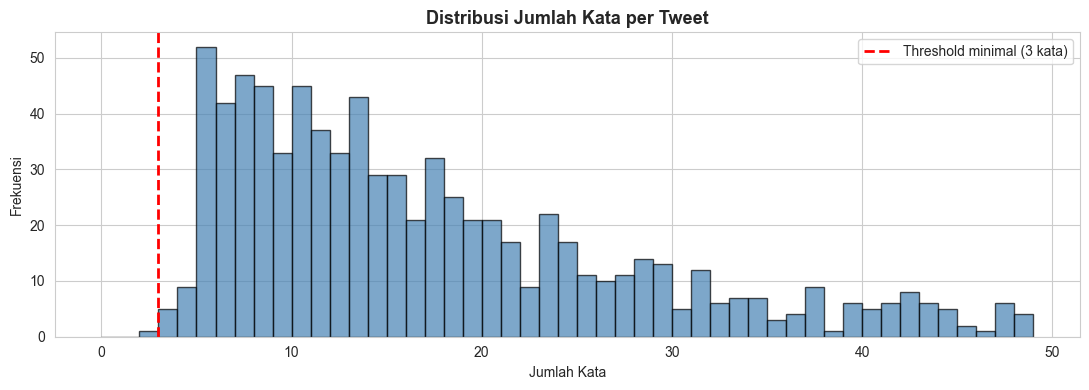

Tweet dengan kurang dari 3 kata: 1

Contoh tweet pendek yang akan dihapus:
  - [Gangguan Jaringan] 'indihome gangguan???'

Tweet pendek yang dihapus: 1
Sisa data: 797


In [19]:
# Hitung panjang tweet (kalau belum dihitung sebelumnya)
df['jumlah_kata'] = df['tweet'].astype(str).str.split().str.len()
df['panjang_karakter'] = df['tweet'].astype(str).str.len()

# Visualisasi: distribusi tweet sangat pendek
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(df['jumlah_kata'], bins=range(0, 50), color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(3, color='red', linestyle='--', linewidth=2, label='Threshold minimal (3 kata)')
ax.set_title('Distribusi Jumlah Kata per Tweet', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Kata')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.savefig('clean_panjang_kata.png', dpi=120, bbox_inches='tight')
plt.show()

# Cek tweet yang sangat pendek
tweet_pendek = df[df['jumlah_kata'] < 3]
print(f"Tweet dengan kurang dari 3 kata: {len(tweet_pendek)}")
if len(tweet_pendek) > 0:
    print("\nContoh tweet pendek yang akan dihapus:")
    for idx, row in tweet_pendek.head(5).iterrows():
        print(f"  - [{row['label']}] '{row['tweet']}'")

# Filter: pertahankan tweet dengan minimal 3 kata
sebelum = len(df)
df = df[df['jumlah_kata'] >= 3].reset_index(drop=True)
sesudah = len(df)
dihapus = sebelum - sesudah

log_cleaning['Setelah filter tweet pendek'] = sesudah
print(f"\nTweet pendek yang dihapus: {dihapus}")
print(f"Sisa data: {sesudah}")

### 1.6.5 Cek Konsistensi Label

Memeriksa apakah semua label yang ada di dataset sesuai dengan kategori yang sudah ditetapkan.
Label yang typo atau tidak valid akan menyebabkan error saat training.

In [20]:
# Daftar label yang valid (sesuai kategori yang sudah ditentukan)
label_valid = ['Gangguan Jaringan', 'Customer Service', 'Masalah Tagihan',
               'Pemutusan', 'Lainnya']

# Cek label unik di dataset
label_di_dataset = df['label'].unique()
print("Label yang ada di dataset:")
for l in label_di_dataset:
    jumlah = (df['label'] == l).sum()
    status = "OK" if l in label_valid else "TIDAK VALID"
    print(f"  [{status}] '{l}' -> {jumlah} tweet")
print()

# Cek label yang tidak valid
label_tidak_valid = [l for l in label_di_dataset if l not in label_valid]
if label_tidak_valid:
    print(f"Ditemukan {len(label_tidak_valid)} label tidak valid: {label_tidak_valid}")
    print("Periksa kembali file CSV Anda untuk memperbaiki typo.")
else:
    print("Semua label valid!")

# Strip whitespace di label (jaga-jaga ada spasi tersembunyi)
df['label'] = df['label'].str.strip()

# Hapus baris dengan label tidak valid (kalau ada)
sebelum = len(df)
df = df[df['label'].isin(label_valid)].reset_index(drop=True)
sesudah = len(df)
dihapus = sebelum - sesudah

log_cleaning['Setelah filter label valid'] = sesudah
if dihapus > 0:
    print(f"\nBaris dengan label tidak valid dihapus: {dihapus}")
print(f"Sisa data: {sesudah}")

Label yang ada di dataset:
  [OK] 'Customer Service' -> 166 tweet
  [OK] 'Gangguan Jaringan' -> 495 tweet
  [OK] 'Masalah Tagihan' -> 44 tweet
  [OK] 'Lainnya' -> 57 tweet
  [OK] 'Pemutusan' -> 35 tweet

Semua label valid!
Sisa data: 797


### 1.6.6 Ringkasan Hasil Data Cleaning

Visualisasi dampak cleaning: berapa banyak data yang hilang di tiap tahap?

RINGKASAN DATA CLEANING
  Data awal                          :  799 (100.0%)
  Setelah hapus missing values       :  799 (100.0%)
  Setelah hapus duplikat             :  798 ( 99.9%)
  Setelah filter tweet pendek        :  797 ( 99.7%)
  Setelah filter label valid         :  797 ( 99.7%)

Total baris dihapus: 2 (0.3%)
Data siap untuk text preprocessing: 797 tweet


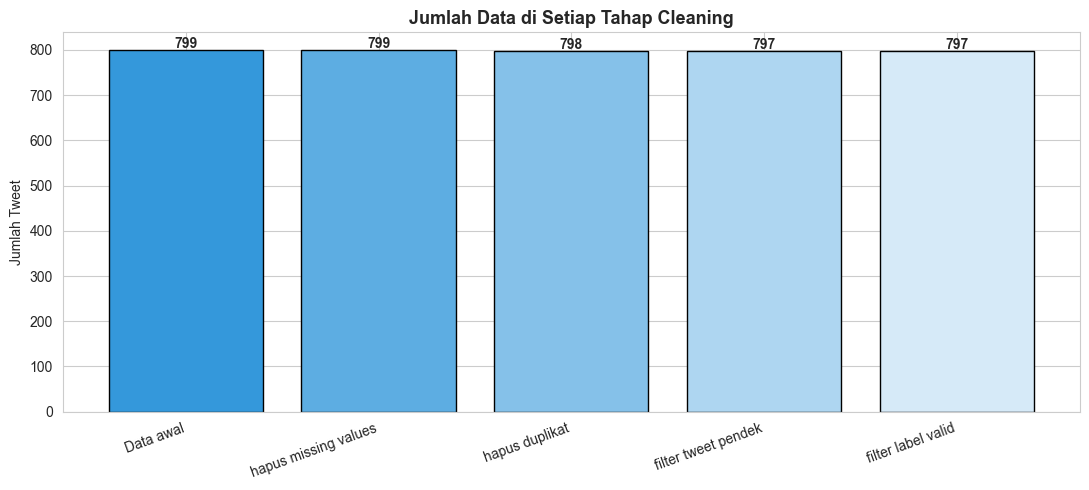


Distribusi label SETELAH cleaning:
label
Gangguan Jaringan    495
Customer Service     166
Lainnya               57
Masalah Tagihan       44
Pemutusan             35
Name: count, dtype: int64


In [22]:
# Tampilkan log cleaning
print("RINGKASAN DATA CLEANING")

for tahap, jumlah in log_cleaning.items():
    selisih = jumlah_awal - jumlah
    persen = (jumlah / jumlah_awal) * 100
    print(f"  {tahap:35s}: {jumlah:4d} ({persen:5.1f}%)")
print()

total_dihapus = jumlah_awal - len(df)
print(f"Total baris dihapus: {total_dihapus} ({total_dihapus/jumlah_awal*100:.1f}%)")
print(f"Data siap untuk text preprocessing: {len(df)} tweet")

# Visualisasi: berkurangnya jumlah data per tahap
plt.figure(figsize=(11, 5))
tahapan = list(log_cleaning.keys())
nilai = list(log_cleaning.values())

bars = plt.bar(range(len(tahapan)), nilai,
               color=['#3498DB', '#5DADE2', '#85C1E9', '#AED6F1', '#D6EAF8'][:len(tahapan)],
               edgecolor='black')
plt.title('Jumlah Data di Setiap Tahap Cleaning', fontsize=13, fontweight='bold')
plt.ylabel('Jumlah Tweet')
plt.xticks(range(len(tahapan)),
           [t.replace('Setelah ', '') for t in tahapan],
           rotation=20, ha='right')

# Anotasi angka di atas bar
for bar, n in zip(bars, nilai):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(n), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('clean_ringkasan.png', dpi=120, bbox_inches='tight')
plt.show()

# Cek distribusi label setelah cleaning (apakah masih seimbang seperti sebelumnya?)
print("\nDistribusi label SETELAH cleaning:")
print(df['label'].value_counts())

## 2. Preprocessing Teks

Tahap membersihkan teks tweet agar siap diolah model. Terdiri dari beberapa langkah:

1. **Case folding** - ubah semua huruf jadi kecil
2. **Cleaning** - hapus URL, mention (@user), hashtag, angka, tanda baca
3. **Normalisasi** - ubah kata gaul/singkatan jadi kata baku (ga -> tidak)
4. **Tokenisasi** - pecah kalimat jadi kata per kata
5. **Stopword removal** - hapus kata umum yang tidak bermakna (yang, di, ke)
6. **Stemming** - ubah kata berimbuhan jadi kata dasar (berlangganan -> langgan)

### 2.1 Case Folding & Cleaning

Mengubah huruf jadi kecil dan menghapus elemen yang tidak diperlukan.

In [23]:
def cleaning_text(teks):
    if not isinstance(teks, str):
        return ""

    # Case folding: ubah ke huruf kecil
    teks = teks.lower()

    # Hapus URL (http, https, www)
    teks = re.sub(r'http\S+|www\.\S+', ' ', teks)

    # Hapus mention @username
    teks = re.sub(r'@\w+', ' ', teks)

    # Hapus hashtag (simbol # saja, katanya tetap dipertahankan)
    teks = re.sub(r'#', ' ', teks)

    # Hapus angka
    teks = re.sub(r'\d+', ' ', teks)

    # Hapus tanda baca
    teks = teks.translate(str.maketrans('', '', string.punctuation))

    # Hapus karakter non-ASCII (emoji, simbol aneh)
    teks = re.sub(r'[^\x00-\x7f]', ' ', teks)

    # Normalisasi spasi berlebih jadi satu spasi
    teks = re.sub(r'\s+', ' ', teks).strip()

    return teks

# Terapkan ke kolom tweet
df['cleaning'] = df['tweet'].apply(cleaning_text)

# Lihat contoh hasil sebelum & sesudah
df[['tweet', 'cleaning']].head(5)

,tweet,cleaning
0,Udah saya coba lebih dari 3x mas. Ga ada perub...,udah saya coba lebih dari x mas ga ada perubah...
1,@IndiHome @IndiHomeCare bayar internet mahal2 ...,bayar internet mahal cuman buat error doang
2,@IndiHomeCare internet di Jl. P. Samudera 3 Pa...,internet di jl p samudera palangka raya dari k...
3,@IndiHomeCare Cek DM min Los di modem,cek dm min los di modem
4,Sdh menyala tp tetap no connection min,sdh menyala tp tetap no connection min


### 2.2 Normalisasi Kata Tidak Baku

Tweet banyak mengandung kata gaul dan singkatan. Kita ubah jadi kata baku agar model lebih mudah mengenali pola.

**Catatan:** kamus di bawah ini bisa Anda tambah sendiri sesuai kata-kata yang sering muncul di dataset Anda.

In [24]:
# Kamus normalisasi
kamus_normalisasi = {
    'ga': 'tidak', 'gak': 'tidak', 'gk': 'tidak', 'ngga': 'tidak',
    'nggak': 'tidak', 'kagak': 'tidak', 'engga': 'tidak',
    'bgt': 'banget', 'bngt': 'banget', 'bener': 'benar',
    'gimana': 'bagaimana', 'gmn': 'bagaimana', 'knp': 'kenapa',
    'napa': 'kenapa', 'udah': 'sudah', 'udh': 'sudah', 'dah': 'sudah',
    'blm': 'belum', 'belom': 'belum', 'lg': 'lagi', 'lgi': 'lagi',
    'aja': 'saja', 'aj': 'saja', 'dr': 'dari', 'dri': 'dari',
    'sm': 'sama', 'tp': 'tapi', 'tpi': 'tapi', 'krn': 'karena',
    'karna': 'karena', 'utk': 'untuk', 'buat': 'untuk', 'jd': 'jadi',
    'jdi': 'jadi', 'sy': 'saya', 'gw': 'saya', 'gua': 'saya',
    'gue': 'saya', 'lu': 'kamu', 'lo': 'kamu', 'min': 'admin',
    'kak': 'kakak', 'inet': 'internet', 'lemot': 'lambat',
    'lelet': 'lambat', 'pls': 'tolong', 'plis': 'tolong',
    'gajelas': 'tidak jelas', 'gabisa': 'tidak bisa',
    'gaada': 'tidak ada', 'sdh': 'sudah'
}

def normalisasi_text(teks):
    """Mengganti kata tidak baku dengan kata baku berdasarkan kamus."""
    kata_kata = teks.split()
    hasil = [kamus_normalisasi.get(kata, kata) for kata in kata_kata]
    return ' '.join(hasil)

# Terapkan
df['normalisasi'] = df['cleaning'].apply(normalisasi_text)

df[['cleaning', 'normalisasi']].head(5)

,cleaning,normalisasi
0,udah saya coba lebih dari x mas ga ada perubah...,sudah saya coba lebih dari x mas tidak ada per...
1,bayar internet mahal cuman buat error doang,bayar internet mahal cuman untuk error doang
2,internet di jl p samudera palangka raya dari k...,internet di jl p samudera palangka raya dari k...
3,cek dm min los di modem,cek dm admin los di modem
4,sdh menyala tp tetap no connection min,sudah menyala tapi tetap no connection admin


### 2.3 Tokenisasi

Memecah kalimat menjadi daftar kata (token).

In [25]:
def tokenisasi_text(teks):
    """Memecah teks menjadi list kata."""
    return teks.split()

df['tokenisasi'] = df['normalisasi'].apply(tokenisasi_text)

df[['normalisasi', 'tokenisasi']].head(5)

,normalisasi,tokenisasi
0,sudah saya coba lebih dari x mas tidak ada per...,"[sudah, saya, coba, lebih, dari, x, mas, tidak..."
1,bayar internet mahal cuman untuk error doang,"[bayar, internet, mahal, cuman, untuk, error, ..."
2,internet di jl p samudera palangka raya dari k...,"[internet, di, jl, p, samudera, palangka, raya..."
3,cek dm admin los di modem,"[cek, dm, admin, los, di, modem]"
4,sudah menyala tapi tetap no connection admin,"[sudah, menyala, tapi, tetap, no, connection, ..."


### 2.4 Stopword Removal

Menghapus kata-kata umum yang tidak membawa makna penting untuk klasifikasi (contoh: yang, di, ke, dari, dan).

In [26]:
# Ambil daftar stopword Bahasa Indonesia dari NLTK
stopword_id = set(stopwords.words('indonesian'))

# Beberapa kata penting yang JANGAN dihapus meski tergolong stopword
kata_dipertahankan = {'tidak', 'belum', 'kurang', 'sulit'}
stopword_id = stopword_id - kata_dipertahankan

print(f"Jumlah stopword yang dipakai: {len(stopword_id)}")

def stopword_removal(token_list):
    """Menghapus stopword dari list token."""
    return [kata for kata in token_list if kata not in stopword_id]

df['stopword_removal'] = df['tokenisasi'].apply(stopword_removal)

df[['tokenisasi', 'stopword_removal']].head(5)

Jumlah stopword yang dipakai: 754


,tokenisasi,stopword_removal
0,"[sudah, saya, coba, lebih, dari, x, mas, tidak...","[coba, x, mas, tidak, perubahan, teknisi]"
1,"[bayar, internet, mahal, cuman, untuk, error, ...","[bayar, internet, mahal, cuman, error, doang]"
2,"[internet, di, jl, p, samudera, palangka, raya...","[internet, jl, p, samudera, palangka, raya, ke..."
3,"[cek, dm, admin, los, di, modem]","[cek, dm, admin, los, modem]"
4,"[sudah, menyala, tapi, tetap, no, connection, ...","[menyala, no, connection, admin]"


### 2.5 Stemming

Mengubah kata berimbuhan menjadi kata dasar menggunakan **Sastrawi** (contoh: "berlangganan" menjadi "langgan", "pembayaran" menjadi "bayar").

**Catatan:** proses stemming agak lama (1-3 menit untuk 799 tweet) karena memproses setiap kata. Tunggu sampai selesai.

In [27]:
# Buat objek stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming_text(token_list):
    """Mengubah setiap kata jadi kata dasar."""
    return [stemmer.stem(kata) for kata in token_list]

print("Proses stemming sedang berjalan, mohon tunggu...")
df['stemming'] = df['stopword_removal'].apply(stemming_text)
print("Stemming selesai.")

df[['stopword_removal', 'stemming']].head(5)

Proses stemming sedang berjalan, mohon tunggu...
Stemming selesai.


,stopword_removal,stemming
0,"[coba, x, mas, tidak, perubahan, teknisi]","[coba, x, mas, tidak, ubah, teknisi]"
1,"[bayar, internet, mahal, cuman, error, doang]","[bayar, internet, mahal, cuman, error, doang]"
2,"[internet, jl, p, samudera, palangka, raya, ke...","[internet, jl, p, samudera, palangka, raya, ke..."
3,"[cek, dm, admin, los, modem]","[cek, dm, admin, los, modem]"
4,"[menyala, no, connection, admin]","[nyala, no, connection, admin]"


### 2.6 Hasil Akhir Preprocessing

Menggabungkan token kembali menjadi kalimat bersih, siap untuk feature extraction.

In [28]:
# Gabungkan list token jadi satu string
df['teks_bersih'] = df['stemming'].apply(lambda token: ' '.join(token))

# Hapus baris yang teks bersihnya kosong (kalau ada) agar tidak error
df = df[df['teks_bersih'].str.strip() != ''].reset_index(drop=True)

print(f"Jumlah data setelah preprocessing: {len(df)}")
print()
print("Contoh perbandingan teks asli vs teks bersih:")
for i in range(3):
    print(f"[{i+1}] ASLI  : {df['tweet'].iloc[i]}")
    print(f"    BERSIH: {df['teks_bersih'].iloc[i]}")
    print()

Jumlah data setelah preprocessing: 797

Contoh perbandingan teks asli vs teks bersih:
[1] ASLI  : Udah saya coba lebih dari 3x mas. Ga ada perubahan. Saya minta teknisi aja.
    BERSIH: coba x mas tidak ubah teknisi

[2] ASLI  : @IndiHome @IndiHomeCare bayar internet mahal2 cuman buat error doang.
    BERSIH: bayar internet mahal cuman error doang

[3] ASLI  : @IndiHomeCare internet di Jl. P. Samudera 3 Palangka Raya dari kemarin sore tidak conect, harap segera diperbaiki.
    BERSIH: internet jl p samudera palangka raya kemarin sore tidak conect harap baik



### 2.7 Visualisasi Hasil Preprocessing

Sebelum lanjut ke feature extraction, mari kita visualisasikan **dampak preprocessing**:
membandingkan teks sebelum dan sesudah dibersihkan.

#### 2.7.1 Perbandingan Panjang Teks Sebelum vs Sesudah

Preprocessing umumnya **memperpendek** teks karena banyak kata umum (stopwords)
dan karakter (URL, mention, angka) yang dihilangkan.

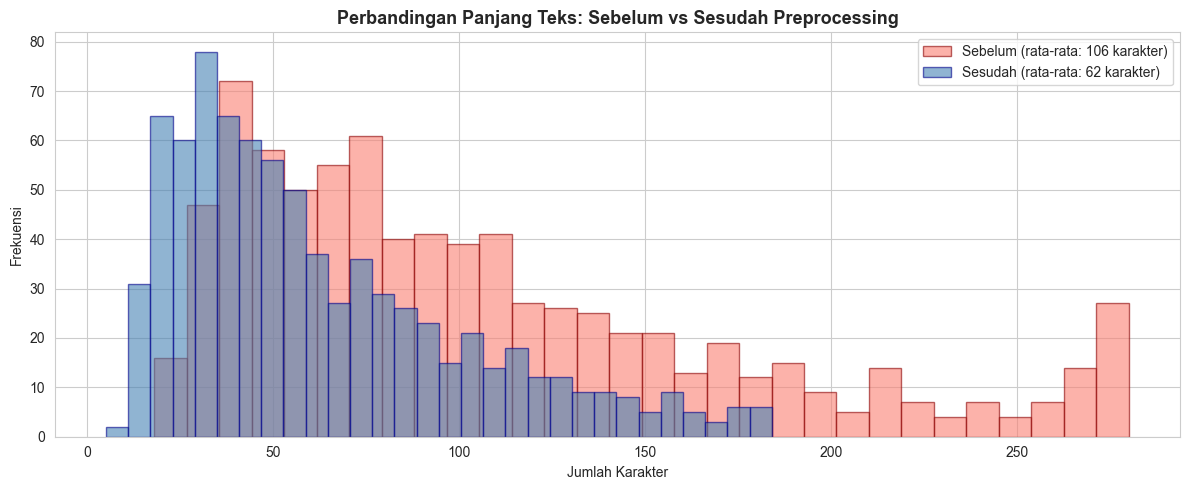

Preprocessing mereduksi panjang teks rata-rata sebesar 42.0%


In [29]:
# Hitung panjang teks sebelum dan sesudah preprocessing
df['panjang_sebelum'] = df['tweet'].astype(str).str.len()
df['panjang_sesudah'] = df['teks_bersih'].str.len()

# Visualisasi: histogram tumpang tindih
plt.figure(figsize=(12, 5))
plt.hist(df['panjang_sebelum'], bins=30, alpha=0.6, color='salmon',
         label=f'Sebelum (rata-rata: {df["panjang_sebelum"].mean():.0f} karakter)',
         edgecolor='darkred')
plt.hist(df['panjang_sesudah'], bins=30, alpha=0.6, color='steelblue',
         label=f'Sesudah (rata-rata: {df["panjang_sesudah"].mean():.0f} karakter)',
         edgecolor='darkblue')
plt.title('Perbandingan Panjang Teks: Sebelum vs Sesudah Preprocessing',
          fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.savefig('viz_panjang_sebelum_sesudah.png', dpi=120, bbox_inches='tight')
plt.show()

reduksi = (1 - df['panjang_sesudah'].mean() / df['panjang_sebelum'].mean()) * 100
print(f"Preprocessing mereduksi panjang teks rata-rata sebesar {reduksi:.1f}%")

#### 2.7.2 Kata yang Paling Sering Muncul (Sesudah Preprocessing)

Setelah preprocessing, kata-kata umum (yang, di, ke) sudah hilang dan tersisa
kata-kata yang **lebih bermakna** untuk klasifikasi keluhan.

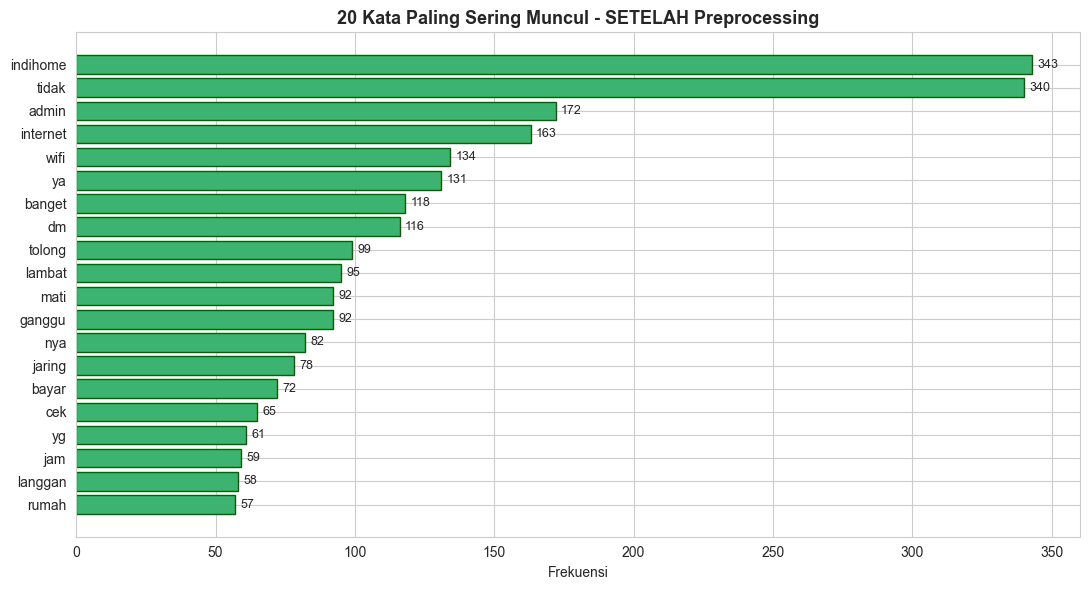

Bandingkan dengan Top 20 SEBELUM preprocessing - sekarang lebih bermakna!


In [30]:
# Gabung semua teks bersih, hitung kata paling sering
semua_kata_bersih = ' '.join(df['teks_bersih']).split()
counter_bersih = Counter(semua_kata_bersih)
top20_bersih = counter_bersih.most_common(20)

# Visualisasi
kata, jumlah = zip(*top20_bersih)
plt.figure(figsize=(11, 6))
bars = plt.barh(range(len(kata)), jumlah, color='mediumseagreen', edgecolor='darkgreen')
plt.yticks(range(len(kata)), kata)
plt.gca().invert_yaxis()
plt.title('20 Kata Paling Sering Muncul - SETELAH Preprocessing',
          fontsize=13, fontweight='bold')
plt.xlabel('Frekuensi')

for i, jml in enumerate(jumlah):
    plt.text(jml + 2, i, str(jml), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz_top20_sesudah.png', dpi=120, bbox_inches='tight')
plt.show()

print("Bandingkan dengan Top 20 SEBELUM preprocessing - sekarang lebih bermakna!")

#### 2.7.3 WordCloud Keseluruhan

WordCloud memvisualisasikan **kata-kata dominan** dalam dataset.
Semakin besar ukuran kata, semakin sering kata itu muncul.

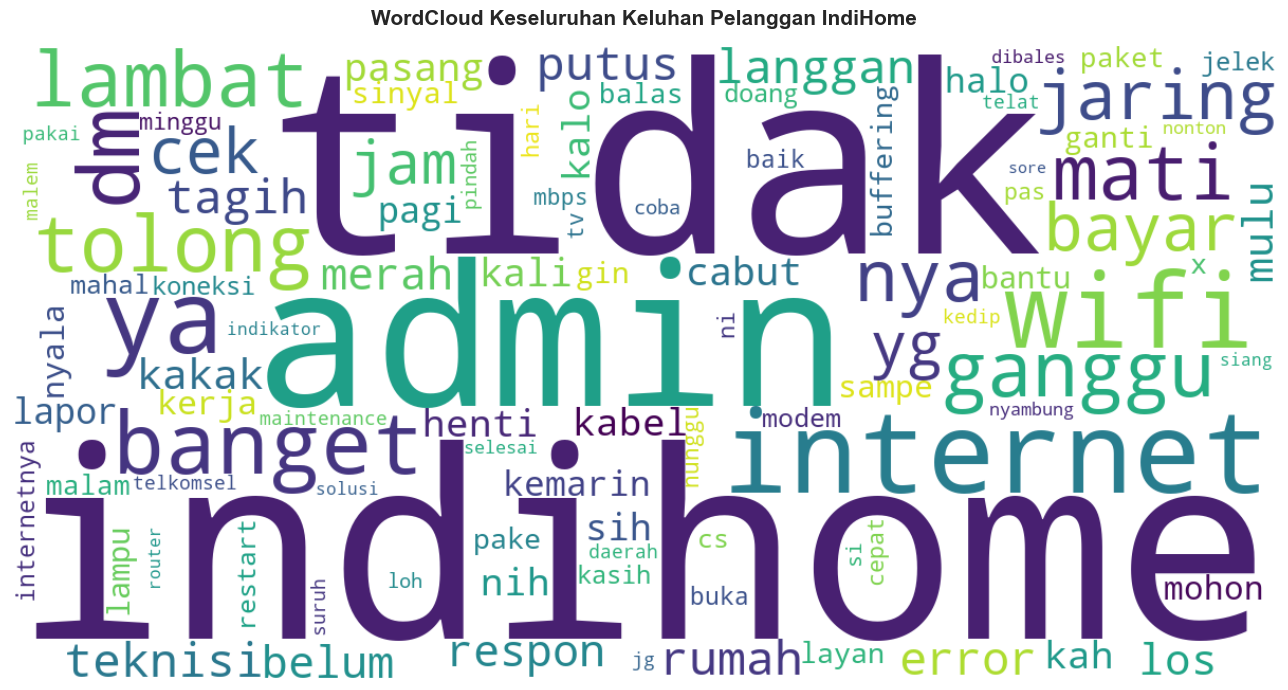

WordCloud disimpan sebagai: viz_wordcloud_keseluruhan.png


In [31]:
# WordCloud dari seluruh teks bersih
semua_teks = ' '.join(df['teks_bersih'])

wordcloud = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='viridis',
    max_words=100,
    random_state=42,
    collocations=False  # hindari duplikasi pasangan kata
).generate(semua_teks)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Keseluruhan Keluhan Pelanggan IndiHome',
          fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()

# Simpan untuk laporan
wordcloud.to_file('viz_wordcloud_keseluruhan.png')
plt.savefig('viz_wordcloud_keseluruhan_full.png', dpi=120, bbox_inches='tight')
plt.show()

print("WordCloud disimpan sebagai: viz_wordcloud_keseluruhan.png")

## 3. Feature Extraction dengan TF-IDF

Model machine learning tidak bisa memproses teks secara langsung - teks harus diubah jadi angka.

**TF-IDF (Term Frequency-Inverse Document Frequency)** mengubah setiap tweet menjadi vektor angka. Kata yang sering muncul di satu tweet tapi jarang di tweet lain akan mendapat bobot tinggi (dianggap penting/khas).

In [32]:
# Pisahkan fitur (X) dan label (y)
X = df['teks_bersih']      # teks tweet yang sudah bersih
y = df['label']            # kategori keluhan

# Buat objek TF-IDF Vectorizer
# max_features membatasi jumlah kata unik agar model tidak terlalu kompleks
tfidf = TfidfVectorizer(max_features=2000)

# Ubah teks jadi matriks angka
X_tfidf = tfidf.fit_transform(X)

print(f"Bentuk matriks TF-IDF: {X_tfidf.shape}")
print(f"  -> {X_tfidf.shape[0]} tweet, masing-masing jadi vektor {X_tfidf.shape[1]} angka")

Bentuk matriks TF-IDF: (797, 1780)
  -> 797 tweet, masing-masing jadi vektor 1780 angka


## 4. Membagi Data: Training & Testing

Dataset dibagi dua:
- **Data training (80%)** - untuk melatih model
- **Data testing (20%)** - untuk menguji model pada data yang belum pernah dilihat

`stratify=y` memastikan proporsi tiap kategori tetap seimbang di kedua bagian.

In [33]:
# Bagi data 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,    # angka tetap agar hasil bisa direproduksi
    stratify=y          # jaga proporsi tiap kelas
)

print(f"Data training: {X_train.shape[0]} tweet")
print(f"Data testing : {X_test.shape[0]} tweet")

Data training: 637 tweet
Data testing : 160 tweet


## 5. Melatih Model SVM

**Support Vector Machine (SVM)** dilatih untuk mengenali pola kata di setiap kategori keluhan.

`class_weight='balanced'` digunakan untuk mengatasi **class imbalance** - karena kategori "Gangguan Jaringan" jauh lebih banyak dari kategori lain, parameter ini memberi bobot lebih besar ke kategori minoritas agar model tetap belajar adil.

In [34]:
# Buat dan latih model SVM
model_svm = SVC(
    kernel='linear',           # kernel linear cocok untuk klasifikasi teks
    class_weight='balanced',   # mengatasi ketidakseimbangan kelas
    random_state=42
)

# Proses training
model_svm.fit(X_train, y_train)

print("Model SVM berhasil dilatih.")

Model SVM berhasil dilatih.


## 6. Evaluasi Model

Mengukur seberapa baik model dengan beberapa metrik:
- **Accuracy** - persentase prediksi yang benar secara keseluruhan
- **Precision** - dari yang diprediksi kategori X, berapa yang benar
- **Recall** - dari yang sebenarnya kategori X, berapa yang berhasil ditemukan
- **F1-score** - rata-rata harmonik precision dan recall

In [35]:
# Model memprediksi data testing
y_pred = model_svm.predict(X_test)

# Hitung akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi model: {akurasi:.4f} ({akurasi*100:.2f}%)")
print()

# Laporan lengkap precision, recall, F1 per kategori
print("Laporan klasifikasi per kategori:")
print(classification_report(y_test, y_pred))

Akurasi model: 0.7500 (75.00%)

Laporan klasifikasi per kategori:
                   precision    recall  f1-score   support

 Customer Service       0.57      0.70      0.63        33
Gangguan Jaringan       0.80      0.85      0.82        99
          Lainnya       0.75      0.25      0.38        12
  Masalah Tagihan       0.80      0.44      0.57         9
        Pemutusan       1.00      0.86      0.92         7

         accuracy                           0.75       160
        macro avg       0.78      0.62      0.66       160
     weighted avg       0.76      0.75      0.74       160



### 6.1 Confusion Matrix

Tabel yang menunjukkan di mana model benar dan di mana model salah. Diagonal = prediksi benar. Di luar diagonal = kesalahan klasifikasi.

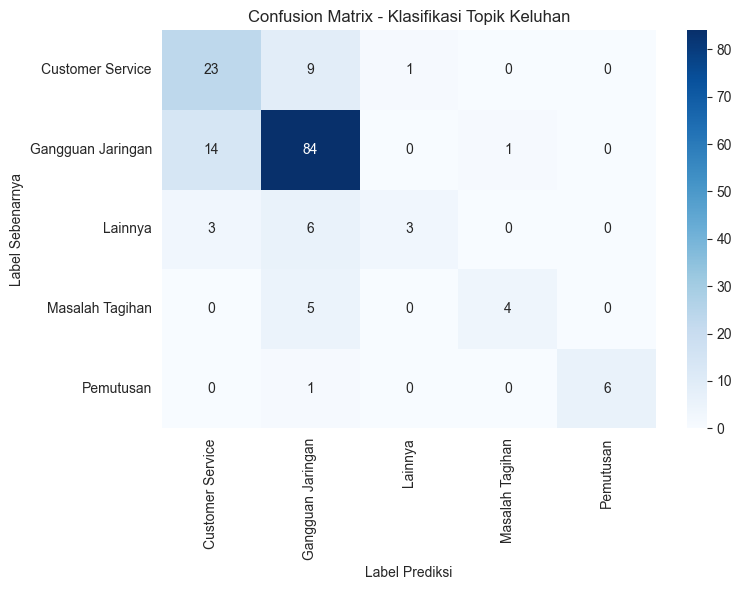

In [36]:
# Buat confusion matrix
label_unik = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=label_unik)

# Visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_unik, yticklabels=label_unik)
plt.title('Confusion Matrix - Klasifikasi Topik Keluhan')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.show()

## 7. Uji Coba Model dengan Tweet Baru

Mencoba model pada kalimat baru yang tidak ada di dataset. Ini berguna untuk demo saat presentasi.

In [38]:
def prediksi_keluhan(teks_baru):
    """Memprediksi kategori dari sebuah tweet baru."""
    # Teks baru harus melalui preprocessing yang sama
    bersih = cleaning_text(teks_baru)
    bersih = normalisasi_text(bersih)
    token = tokenisasi_text(bersih)
    token = stopword_removal(token)
    token = stemming_text(token)
    teks_final = ' '.join(token)

    # Ubah ke TF-IDF lalu prediksi
    vektor = tfidf.transform([teks_final])
    hasil = model_svm.predict(vektor)[0]
    return hasil

# Contoh uji coba
contoh_tweet = [
    "internet saya putus putus dari kemarin tolong diperbaiki",
    "kenapa tagihan bulan ini naik tiba tiba",
    "DM saya dari kemarin tidak dibalas admin",
    "mau berhenti berlangganan indihome gimana caranya",
]

print("Hasil Uji Coba")
print()
for tweet in contoh_tweet:
    kategori = prediksi_keluhan(tweet)
    print(f"Tweet    : {tweet}")
    print(f"Prediksi : {kategori}")
    print()

Hasil Uji Coba

Tweet    : internet saya putus putus dari kemarin tolong diperbaiki
Prediksi : Gangguan Jaringan

Tweet    : kenapa tagihan bulan ini naik tiba tiba
Prediksi : Masalah Tagihan

Tweet    : DM saya dari kemarin tidak dibalas admin
Prediksi : Customer Service

Tweet    : mau berhenti berlangganan indihome gimana caranya
Prediksi : Pemutusan



## 8. Menyimpan Model

Menyimpan model SVM dan TF-IDF vectorizer ke file agar bisa dipakai lagi tanpa training ulang. **File `.pkl` inilah "AI" hasil penelitian Anda** yang bisa ditunjukkan saat presentasi.

In [39]:
import joblib

# Simpan model dan vectorizer
joblib.dump(model_svm, 'model_svm_indihome.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model berhasil disimpan:")
print("  - model_svm_indihome.pkl  (model AI hasil training)")
print("  - tfidf_vectorizer.pkl    (pengubah teks ke angka)")
print()

import os
print("File tersimpan di:", os.getcwd())
print("Cari: model_svm_indihome.pkl dan tfidf_vectorizer.pkl")

Model berhasil disimpan:
  - model_svm_indihome.pkl  (model AI hasil training)
  - tfidf_vectorizer.pkl    (pengubah teks ke angka)

File tersimpan di: c:\Kulyeah\SEMESTER 6\KECERDASAN AI\Tugas Besar\Code
Cari: model_svm_indihome.pkl dan tfidf_vectorizer.pkl
